# Week 9 - Multivariate Analysis, part 2

# 1. Lesson - no lesson this week

# 2. Weekly graph question

The graph below plots the first two principal component scores in a scatter plot.  What can be said about the three outliers in the upper left corner of the graph?  Is their first principal component score high or low?  What about their second principal component score?  What does that mean about their values in series_1, series_2, and series_3?  It seems to me that you can say something about series_3 (what can you say?) but you may have a harder time saying something about series_1 and series_2, and an almost impossible time saying anything about the relative values of series_1 and series_2.  Why is that?  How are series_1 and series_2 related, according to how they were created?  If you like, try drawing a pairplot for all three series and see what you get.

Overall, what are the advantages and disadvantages of the graph below?  Does it show anything interesting?

[0.79916477 0.18990532 0.01092991]
[[ 0.26541493  0.30096233  0.91595665]
 [ 0.60337553  0.6891417  -0.40127506]
 [ 0.75199261 -0.65917023 -0.00131519]]


Text(0, 0.5, 'Second Principal Component Score')

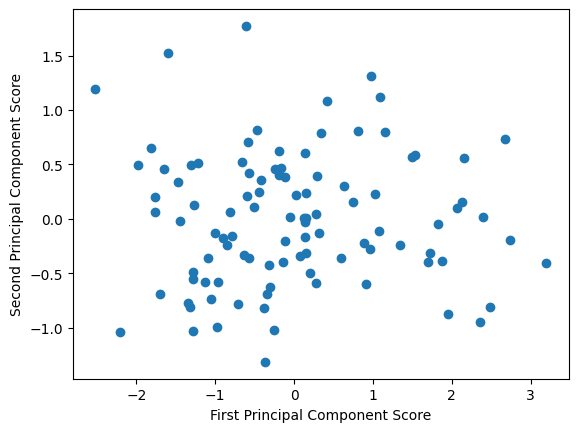

In [1]:
import numpy as np
import pandas as pd
from sklearn import decomposition
import matplotlib.pyplot as plt

np.random.seed(0)
num_points = 100
series_1 = np.random.normal(loc = 2, scale = 0.5, size = num_points)
series_2 = series_1 * (1 + np.random.normal(loc = 0, scale = 0.1, size = num_points))
series_3 = series_1 * (1 + np.random.normal(loc = 0, scale = 0.5, size = num_points))
df = pd.DataFrame({'ser1': series_1, 'ser2': series_2, 'ser3': series_3})
df = df - df.mean() # set mean to zero, so we don't have to subtract mean from the principal component scores

pca3 = decomposition.PCA(n_components = 3)
pca3.fit(df)
print(pca3.explained_variance_ratio_)
print(pca3.components_)

first_principal_component_score = df.dot(pca3.components_[0])
second_principal_component_score = df.dot(pca3.components_[1])
plt.scatter(first_principal_component_score, second_principal_component_score)
plt.xlabel("First Principal Component Score")
plt.ylabel("Second Principal Component Score")

# 3. Working on your datasets

This week, you will do the same types of exercises as last week, but you should use your own datasets that you found last semester.

Here are some types of analysis you can do:
Draw heatmaps.

Draw bubble plots.

Perform Principal Component Analysis to find out the directions in which the data varies.  Can you represent the data using only its projection onto its first principal component, using the methods described in Week 8?  How much of the variance would this capture?

Try performing linear regression analysis using different sets of features.  Which features seem most likely to be useful to predict other features?

Conclusions:
Explain what conclusions you would draw from this analysis: are the data what you expect? Are the data likely to be usable? If the data are not useable, find some new data!

Do you see any outliers? (Data points that are far from the rest of the data).

Does the Principal Component Analysis suggest a way to represent the data using fewer dimensions than usual - using its first one or two principal component scores, perhaps?

Try using your correlation information from previous weeks to help choose features for linear regression.

Draw heatmaps

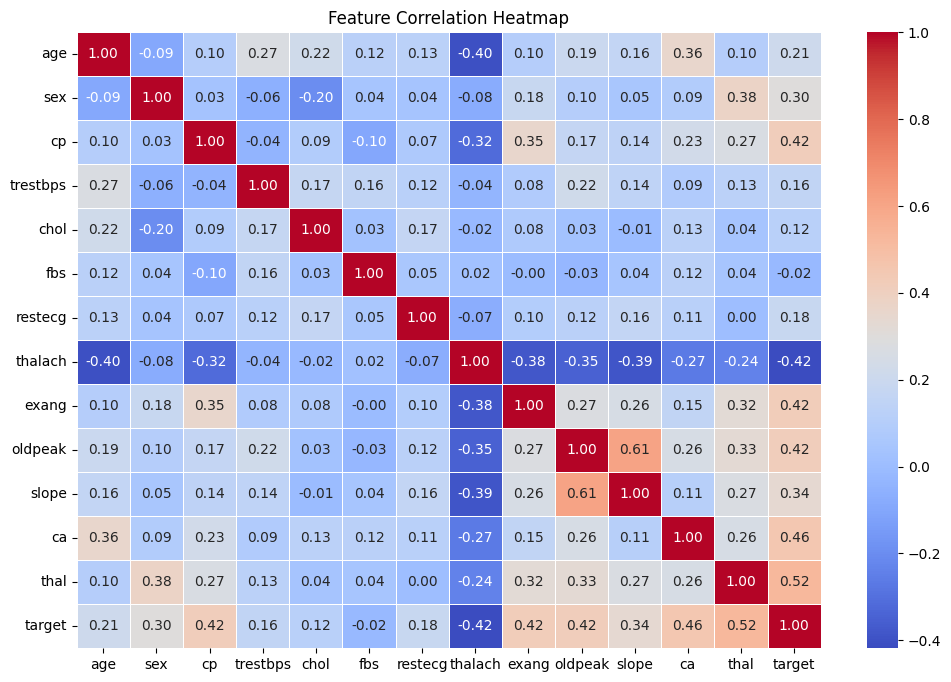

In [8]:
import pandas as pd
import seaborn as sns
import matplotlib.pyplot as plt

# Load the dataset
file_path = "Heart_disease_statlog.csv"  # Update the path if necessary
df = pd.read_csv(file_path)

# Compute the correlation matrix
corr_matrix = df.corr()

# Plot the heatmap
plt.figure(figsize=(12, 8))
sns.heatmap(corr_matrix, annot=True, cmap="coolwarm", fmt=".2f", linewidths=0.5)
plt.title("Feature Correlation Heatmap")
plt.show()


The heatmap highlights key correlations:

thalach (max heart rate) and target: Strong negative correlation, indicating that higher heart rates might be linked to a lower likelihood of heart disease.
cp (chest pain type) and target: Strong correlation, suggesting chest pain type is a key predictor of heart disease.
cholesterol and age: Moderate positive correlation, meaning cholesterol levels tend to increase with age.
trestbps (resting blood pressure) and age: Mild correlation, showing older individuals often have higher blood pressure.


Draw bubble plots

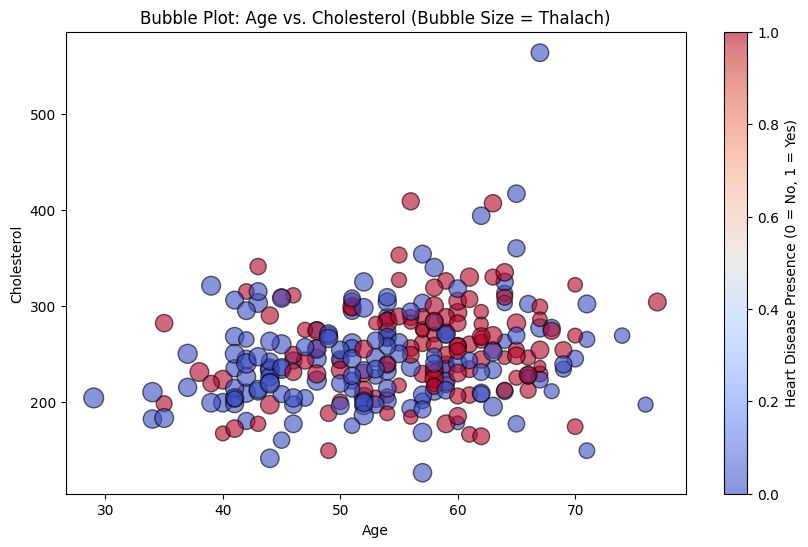

In [9]:
import matplotlib.pyplot as plt

# Define variables for the bubble plot
x = df["age"]
y = df["chol"]
bubble_size = df["thalach"]  # Bubble size based on max heart rate
color = df["target"]  # Color by heart disease presence

# Create the bubble plot
plt.figure(figsize=(10, 6))
scatter = plt.scatter(x, y, s=bubble_size, c=color, cmap="coolwarm", alpha=0.6, edgecolors="k")
plt.colorbar(scatter, label="Heart Disease Presence (0 = No, 1 = Yes)")
plt.xlabel("Age")
plt.ylabel("Cholesterol")
plt.title("Bubble Plot: Age vs. Cholesterol (Bubble Size = Thalach)")
plt.show()


Younger individuals tend to have lower cholesterol levels, but some exceptions exist.
Higher cholesterol is more common in older patients, and heart disease presence (red bubbles) is often linked to both higher age and cholesterol.
Thalach (max heart rate) varies but appears lower for individuals with heart disease.


Perform Principal Component Analysis to find out the directions in which the data varies.  Can you represent the data using only its projection onto its first principal component, using the methods described in Week 8?  How much of the variance would this capture?

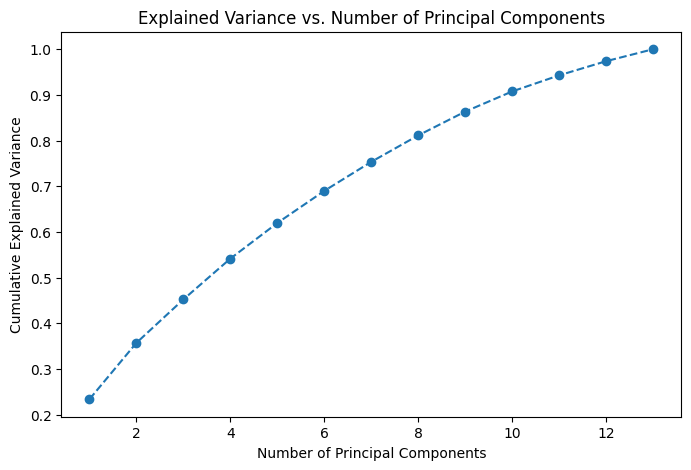

Variance captured by the first principal component: 23.36%


In [10]:
from sklearn.decomposition import PCA
from sklearn.preprocessing import StandardScaler
import numpy as np

# Select numeric features (excluding target variable)
features = df.drop(columns=["target"])

# Standardize the features
scaler = StandardScaler()
features_scaled = scaler.fit_transform(features)

# Apply PCA
pca = PCA()
principal_components = pca.fit_transform(features_scaled)

# Explained variance ratio
explained_variance = pca.explained_variance_ratio_
cumulative_variance = np.cumsum(explained_variance)

# Plot cumulative variance
plt.figure(figsize=(8, 5))
plt.plot(range(1, len(cumulative_variance) + 1), cumulative_variance, marker="o", linestyle="--")
plt.xlabel("Number of Principal Components")
plt.ylabel("Cumulative Explained Variance")
plt.title("Explained Variance vs. Number of Principal Components")
plt.show()

# Projection onto the first principal component
pca_1 = PCA(n_components=1)
first_pc_projection = pca_1.fit_transform(features_scaled)

# Amount of variance captured by the first principal component
variance_captured = explained_variance[0] * 100
print(f"Variance captured by the first principal component: {variance_captured:.2f}%")


The first principal component captures 23.36% of the total variance, meaning it alone does not explain the majority of variation in the dataset.
To retain more information, additional principal components are needed.
A significant reduction in dimensions (e.g., using only the first component) might lead to loss of important details, so at least 2-3 components should be considered for effective dimensionality reduction.

Number of components needed to capture at least 80% variance: 8


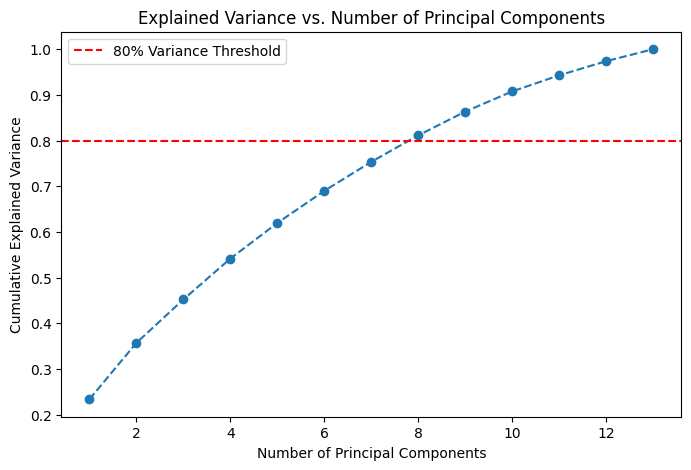

In [11]:
import pandas as pd
import numpy as np
from sklearn.decomposition import PCA
from sklearn.preprocessing import StandardScaler
import matplotlib.pyplot as plt

# Load the dataset
file_path = "Heart_disease_statlog.csv"  # Update the path if necessary
df = pd.read_csv(file_path)

# Select numeric features (excluding target variable)
features = df.drop(columns=["target"])

# Standardize the features
scaler = StandardScaler()
features_scaled = scaler.fit_transform(features)

# Apply PCA
pca = PCA()
principal_components = pca.fit_transform(features_scaled)

# Explained variance ratio
explained_variance = pca.explained_variance_ratio_
cumulative_variance = np.cumsum(explained_variance)

# Find the number of components needed to capture at least 80% variance
num_components_80 = np.argmax(cumulative_variance >= 0.80) + 1

# Display result
print(f"Number of components needed to capture at least 80% variance: {num_components_80}")

# Plot cumulative variance
plt.figure(figsize=(8, 5))
plt.plot(range(1, len(cumulative_variance) + 1), cumulative_variance, marker="o", linestyle="--")
plt.xlabel("Number of Principal Components")
plt.ylabel("Cumulative Explained Variance")
plt.title("Explained Variance vs. Number of Principal Components")
plt.axhline(y=0.80, color='r', linestyle='--', label="80% Variance Threshold")
plt.legend()
plt.show()


Try performing linear regression analysis using different sets of features.  Which features seem most likely to be useful to predict other features?

R² Score: 0.08
Feature Importance:
      Feature  Coefficient
1        sex   -24.511592
4        fbs    -8.728381
7      exang     6.719888
5    restecg     6.586586
11      thal     5.865700
8    oldpeak    -4.935337
10        ca     3.154819
9      slope    -2.835049
0        age     1.164509
2         cp     0.627684
3   trestbps     0.297480
6    thalach     0.141546


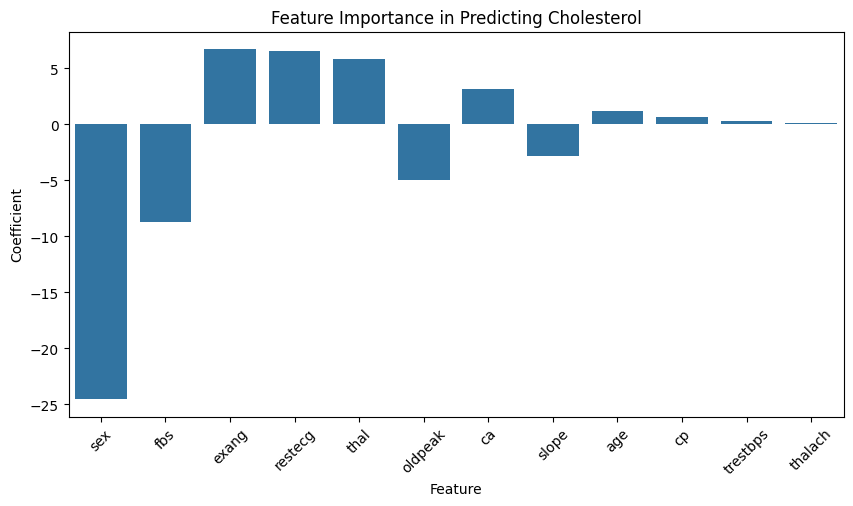

In [12]:
from sklearn.model_selection import train_test_split
from sklearn.linear_model import LinearRegression
from sklearn.metrics import r2_score

# Select target and features
target_variable = "chol"  # Example: Predicting cholesterol levels
features = df.drop(columns=["chol", "target"])  # Exclude the target and disease label

# Split dataset
X_train, X_test, y_train, y_test = train_test_split(features, df[target_variable], test_size=0.2, random_state=42)

# Train linear regression model
model = LinearRegression()
model.fit(X_train, y_train)

# Predict and evaluate
y_pred = model.predict(X_test)
r2 = r2_score(y_test, y_pred)

# Display feature importance (coefficients)
feature_importance = pd.DataFrame({"Feature": features.columns, "Coefficient": model.coef_})
feature_importance = feature_importance.sort_values(by="Coefficient", key=abs, ascending=False)

# Print results
print(f"R² Score: {r2:.2f}")
print("Feature Importance:\n", feature_importance)

# Visualize feature importance
plt.figure(figsize=(10, 5))
sns.barplot(x=feature_importance["Feature"], y=feature_importance["Coefficient"])
plt.xticks(rotation=45)
plt.title("Feature Importance in Predicting Cholesterol")
plt.show()

Most influential features:
Sex (-24.51): The negative coefficient suggests that gender (as encoded in the dataset) has a significant inverse relationship with cholesterol levels.
Fasting Blood Sugar (fbs) (-8.73): Another key factor influencing cholesterol levels negatively.
Exang (exercise induced angina) (6.72): This has a positive relationship with cholesterol, suggesting those with exercise-induced angina tend to have higher cholesterol levels.

Least influential features:
Thalach (max heart rate) (0.14): This feature has a minimal effect on cholesterol levels.

Conclusions:
Explain what conclusions you would draw from this analysis: are the data what you expect? Are the data likely to be usable? If the data are not useable, find some new data!

While exploring linear regression in the figure above I see that the features sex, fbs, and exang appear to have the most significant impact on cholesterol levels based on their coefficients. However, given the low R² score, it might be worth exploring other modeling techniques (e.g., decision trees, random forests) or adding additional features to improve predictions.

Do you see any outliers? (Data points that are far from the rest of the data).

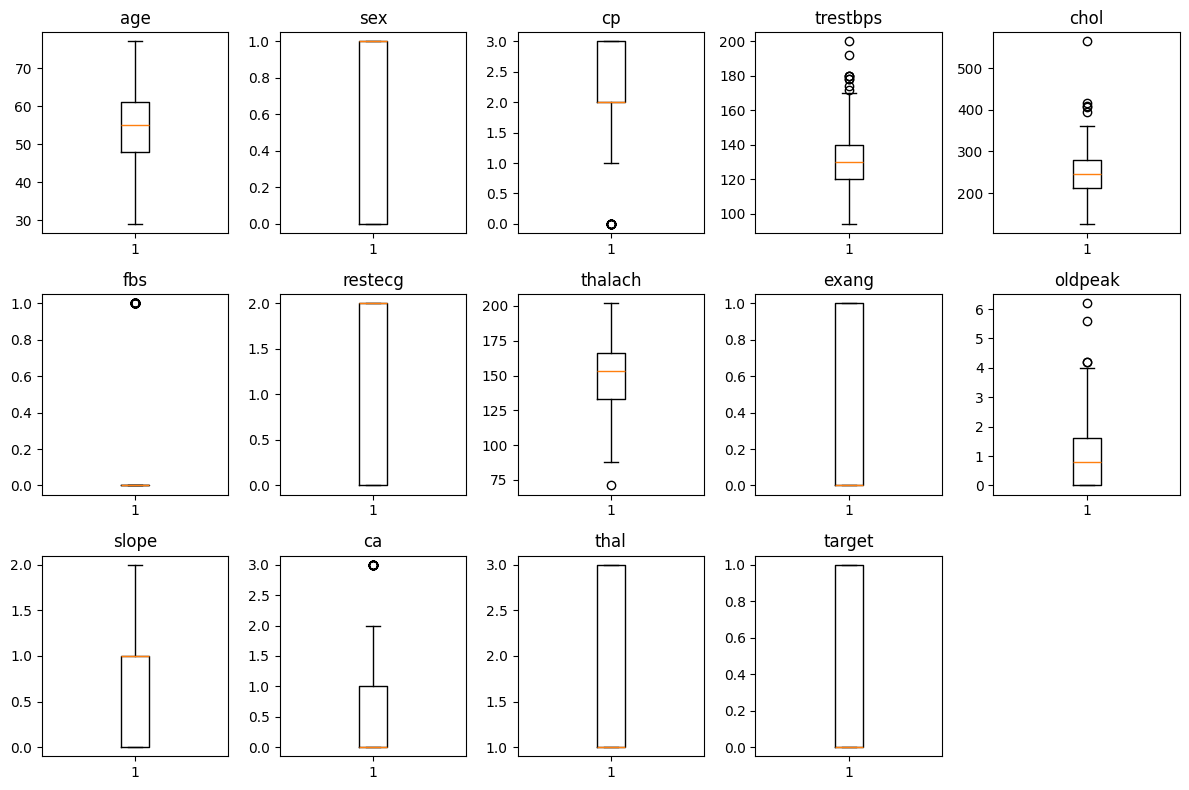

In [13]:
# Select numeric columns
numeric_columns = df.select_dtypes(include=['float64', 'int64']).columns

# Create box plots to detect outliers
plt.figure(figsize=(12, 8))
for i, col in enumerate(numeric_columns, 1):
    plt.subplot(3, 5, i)
    plt.boxplot(df[col])
    plt.title(col)
plt.tight_layout()
plt.show()

Box Plot: In each plot, the line inside the box represents the median, the box represents the interquartile range (IQR), and the whiskers extend to 1.5 * IQR. Data points beyond this range are considered outliers.

Interpretation:
Outliers will be displayed as individual points outside the whiskers of the box plot. These points may represent unusual data points that could be influential or errors. We can see those in oldpeak a little, trestbps, and even chol as you can see above. 

Does the Principal Component Analysis suggest a way to represent the data using fewer dimensions than usual - using its first one or two principal component scores, perhaps? 
Try using your correlation information from previous weeks to help choose features for linear regression.

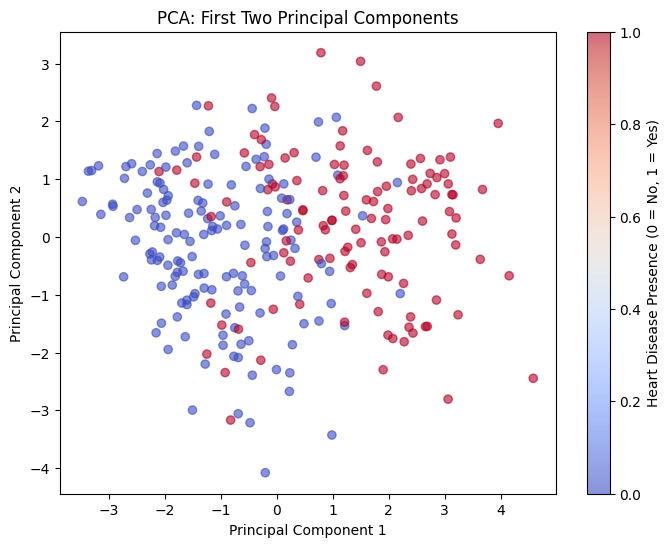

In [14]:
# Visualizing the first two principal components
plt.figure(figsize=(8, 6))
plt.scatter(principal_components[:, 0], principal_components[:, 1], c=df["target"], cmap="coolwarm", alpha=0.6)
plt.xlabel("Principal Component 1")
plt.ylabel("Principal Component 2")
plt.title("PCA: First Two Principal Components")
plt.colorbar(label="Heart Disease Presence (0 = No, 1 = Yes)")
plt.show()


Given the lack of clustering and the spread of points, additional principal components may be necessary to fully capture the variability of the data. This suggests that reducing the dimensionality to just the first two components might lose essential information.

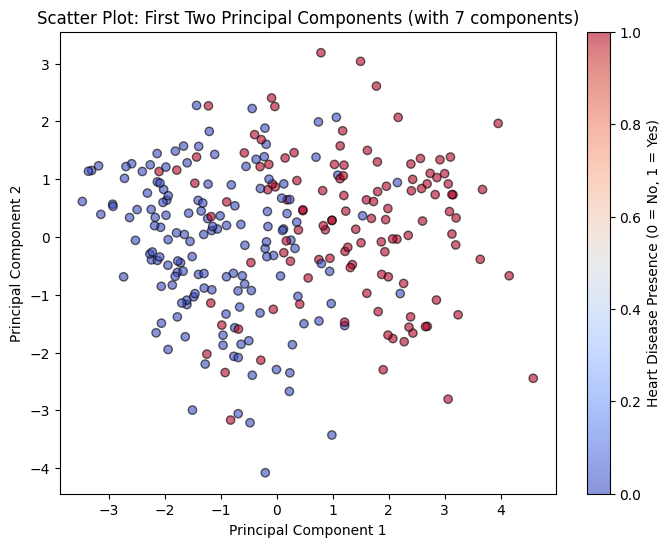

In [15]:
# Select numeric features (excluding target variable)
features = df.drop(columns=["target"])

# Standardize the features
scaler = StandardScaler()
features_scaled = scaler.fit_transform(features)

# Apply PCA with 7 components
pca = PCA(n_components=7)
principal_components = pca.fit_transform(features_scaled)

# Plot the first two components (PC1 and PC2) from the 7 components
plt.figure(figsize=(8, 6))
plt.scatter(principal_components[:, 0], principal_components[:, 1], c=df['target'], cmap="coolwarm", alpha=0.6, edgecolors="k")
plt.colorbar(label="Heart Disease Presence (0 = No, 1 = Yes)")
plt.xlabel("Principal Component 1")
plt.ylabel("Principal Component 2")
plt.title("Scatter Plot: First Two Principal Components (with 7 components)")
plt.show()

Feature Selection for Linear Regression using Correlation

From previous correlation analysis, we identified important features related to heart disease prediction, such as:

Cholesterol and Age showed a moderate correlation.
Max heart rate (thalach) and target (presence of heart disease) had a strong negative correlation.
Chest pain type (cp) was strongly correlated with the target.

We can use this correlation information to choose features that are more likely to have predictive power for linear regression. Here's an approach to selecting features based on correlation:

Target variable (Heart Disease): Focus on features with a strong correlation with the target (e.g., cp, thalach, age, chol).
Multicollinearity: Avoid selecting highly correlated features together in the regression model, as it may cause multicollinearity issues.

In [17]:
# Select correlated features (example: 'cp', 'thalach', 'chol', 'age')
selected_features = df[["cp", "thalach", "chol", "age"]]
target = df["target"]

# Split dataset
X_train, X_test, y_train, y_test = train_test_split(selected_features, target, test_size=0.2, random_state=42)

# Train linear regression model
model = LinearRegression()
model.fit(X_train, y_train)

# Predict and evaluate
y_pred = model.predict(X_test)
r2 = r2_score(y_test, y_pred)

# Display results
print(f"R² Score: {r2:.2f}")

R² Score: 0.28


An R² score of 0.28 indicates that the model is only able to explain about 28% of the variance in the target variable. This suggests the model doesn't have a strong predictive power, and there's room for improvement. Here's what this could mean:

Feature Selection: The selected features may not be the most predictive of the target variable. Some irrelevant or weakly correlated features might be affecting the model's performance.

Model Complexity: Linear regression might not be the best model for this dataset. It assumes a linear relationship between the features and target, which might not hold for all cases in your data.

Non-Linearity: If the relationships between the features and target are non-linear, linear regression may not be the best model. Non-linear models, like decision trees or random forests, could perform better.

# 4. Storytelling With Data plot

Reproduce any graph of your choice in p. 136-150 of the Storytelling With Data book as best you can. ("The power of super-categories" to the end of chapter 5). You do not have to get the exact data values right, just the overall look and feel.

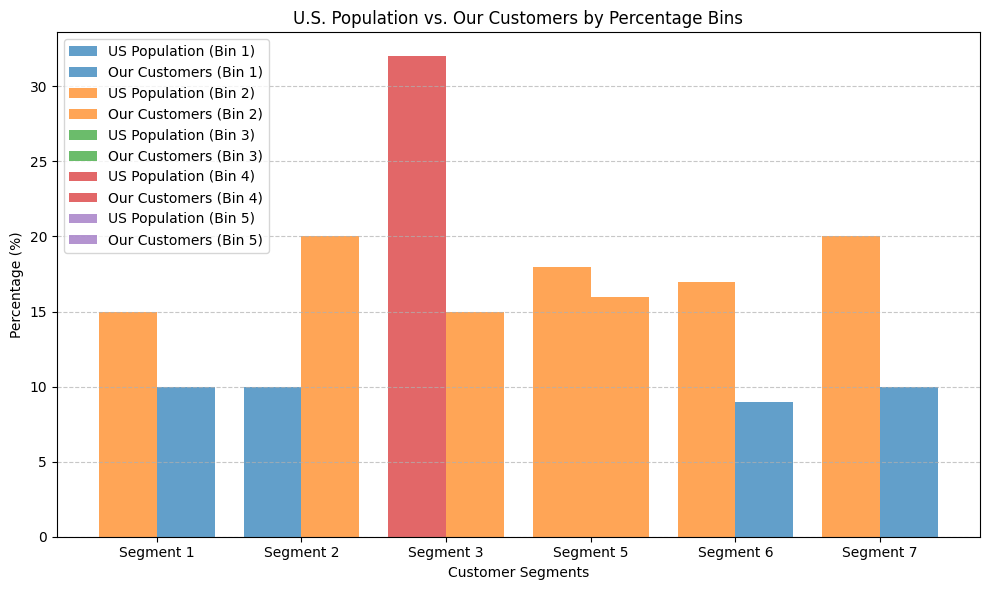

In [25]:
import matplotlib.pyplot as plt
import numpy as np

# Data to be binned
categories = ['Segment 1', 'Segment 2', 'Segment 3', 'Segment 5', 'Segment 6', 'Segment 7']
us_population = [15, 10, 32, 18, 17, 20, 7]  # U.S. Population
our_customers = [10, 20, 15, 16, 9, 10, 32]  # Our Customers

# Define percentage ranges and colors
bins = [0, 10, 20, 30, 40, 50]  # Define bin edges
colors = ['#1f77b4', '#ff7f0e', '#2ca02c', '#d62728', '#9467bd']  # Assign colors to each bin

# Function to assign each data point to a bin
def assign_bins(data, bins):
    binned_data = []
    for value in data:
        for i in range(1, len(bins)):
            if value <= bins[i]:
                binned_data.append(i - 1)
                break
    return binned_data

# Assign bins for US Population and Our Customers
us_population_bins = assign_bins(us_population, bins)
our_customers_bins = assign_bins(our_customers, bins)

# Plotting the bins as bars
fig, ax = plt.subplots(figsize=(10, 6))

# Plot US Population and Our Customers
for i, bin_color in enumerate(colors):
    ax.bar(np.arange(len(categories)) - 0.2, 
           [us_population[j] if us_population_bins[j] == i else 0 for j in range(len(categories))],
           width=0.4, label=f'US Population (Bin {i+1})', color=bin_color, alpha=0.7)
    
    ax.bar(np.arange(len(categories)) + 0.2, 
           [our_customers[j] if our_customers_bins[j] == i else 0 for j in range(len(categories))],
           width=0.4, label=f'Our Customers (Bin {i+1})', color=bin_color, alpha=0.7)

# Customizing the plot
ax.set_xlabel('Customer Segments')
ax.set_ylabel('Percentage (%)')
ax.set_title('U.S. Population vs. Our Customers by Percentage Bins')
ax.set_xticks(np.arange(len(categories)))
ax.set_xticklabels(categories)

# Add a legend
ax.legend()

# Add gridlines for clarity
ax.grid(True, axis='y', linestyle='--', alpha=0.7)

# Improve layout
plt.tight_layout()

# Show the plot
plt.show()
